# Demographics & KPI EDA

This notebook explores customer demographic patterns across the A/B experiment groups and analyzes how demographic variables such as age, gender, and tenure relate to key behavioral KPIs.

The analysis supports the Tableau dashboard and final business interpretation by identifying customer behavior trends, engagement patterns, and potential differences between Test and Control groups.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

## Load Data

We start with the final client-level KPI table because it contains the client demographics, experiment group assignment, and client-level KPI metrics in one table.

We also load the cleaned demographics table only as a sanity check source.

In [2]:
# Load final client-level KPI table
df = pd.read_csv("../data/clean/client_kpi_table.csv")

# Optional sanity-check source: cleaned demographics table
df_demo = pd.read_csv("../data/clean/df_demo_clean.csv")

In [3]:
# Check shape of both datasets

print("Client KPI table shape:", df.shape)
print("Clean demographics table shape:", df_demo.shape)

Client KPI table shape: (50487, 15)
Clean demographics table shape: (70594, 8)


In [4]:
# Check available columns in the client KPI table

df.columns

Index(['client_id', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts',
       'bal', 'calls_6_mnth', 'logons_6_mnth', 'Variation',
       'session_per_client', 'max_step_client', 'completion_rate',
       'avg_steps_client', 'error_rate', 'avg_time_to_completion'],
      dtype='str')

In [5]:
# Preview the client KPI table

df.head()

,client_id,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation,session_per_client,max_step_client,completion_rate,avg_steps_client,error_rate,avg_time_to_completion
0,836976,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,2,4,False,5.5,True,NaN
1,2304905,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control,1,4,False,6.0,True,NaN
2,1439522,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test,2,3,False,2.5,False,NaN
3,1562045,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test,1,0,False,1.0,False,NaN
4,5126305,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control,1,0,False,1.0,False,NaN


## Initial Dataset Exploration & Quality Checks

We first explore the structure and quality of the dataset before analyzing demographic patterns and KPI behavior across experiment groups.

Checks include:
- missing values
- duplicate client IDs
- experiment group distribution
- demographic completeness

In [6]:
# Check missing values

df.isnull().sum()

client_id                     0
clnt_tenure_mnth              0
clnt_age                      0
gendr                         0
num_accts                     0
bal                           0
calls_6_mnth                  0
logons_6_mnth                 0
Variation                     0
session_per_client            0
max_step_client               0
completion_rate               0
avg_steps_client              0
error_rate                    0
avg_time_to_completion    31036
dtype: int64

In [7]:
# Check for duplicate client IDs

df["client_id"].duplicated().sum()

np.int64(0)

In [8]:
# Check Test vs Control distribution

df["Variation"].value_counts()

Variation
Test       26961
Control    23526
Name: count, dtype: int64

In [9]:
# Percentage distribution of experiment groups

df["Variation"].value_counts(normalize=True) * 100

Variation
Test       53.401866
Control    46.598134
Name: proportion, dtype: float64

In [10]:
# Missing values in key demographic columns

df[["clnt_age", "gendr", "clnt_tenure_mnth"]].isnull().sum()

clnt_age            0
gendr               0
clnt_tenure_mnth    0
dtype: int64

In [11]:
# Gender distribution

df["gendr"].value_counts(dropna=False)

gendr
U    17282
M    16947
F    16258
Name: count, dtype: int64

### Initial observations

- The dataset is structured at client level, with one row per client.
- No duplicate client IDs were found.
- The Test and Control groups are well balanced in size, allowing reliable comparison between experiment groups.
- Key demographic variables (age, gender, tenure) contain no missing values.
- The gender column includes many "U" values, representing unknown or unspecified gender.
- The variable `avg_time_to_completion` contains many missing values because it is only available for clients who completed the process.

## Demographic Overview

We first explore the main demographic variables in the client-level KPI table.

This helps us understand the customer base before comparing demographic segments with KPI behavior.

In [12]:
# Summary statistics for key demographic variables

df[["clnt_age", "clnt_tenure_mnth", "num_accts", "bal", "calls_6_mnth", "logons_6_mnth"]].describe()

,clnt_age,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth
count,50487.000000,50487.000000,50487.000000,5.048700e+04,50487.000000,50487.000000
mean,47.319795,150.416365,2.254580,1.495168e+05,3.093272,6.131856
std,15.518616,81.945403,0.533675,3.020390e+05,2.188009,2.175441
min,17.000000,33.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,33.500000,82.000000,2.000000,3.987718e+04,1.000000,4.000000
50%,48.000000,136.000000,2.000000,6.573433e+04,3.000000,6.000000
75%,59.500000,192.000000,2.000000,1.399583e+05,5.000000,8.000000
max,96.000000,669.000000,7.000000,1.632004e+07,6.000000,9.000000


## Create Demographic Segments

To make the demographic analysis easier to interpret in Tableau, we create grouped variables for age and tenure.

In [13]:
# Create age groups for easier comparison

df["age_group"] = pd.cut(
    df["clnt_age"],
    bins=[0, 30, 40, 50, 60, 70, 120],
    labels=["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
)

# Check age group distribution
df["age_group"].value_counts().sort_index()

age_group
<30       9061
30-39     9507
40-49     8788
50-59    11096
60-69     8868
70+       3167
Name: count, dtype: int64

### Demographic observations

- The client base is primarily middle-aged, with the largest groups between 30 and 60 years old.
- Clients aged 50–59 represent the largest age segment in the dataset.
- Very young clients (<30) and older clients (70+) are less represented.
- The average client age is approximately 47 years.
- Most clients have between 1 and 2 accounts.
- Client tenure is relatively high overall, suggesting that many users are long-term Vanguard customers.
- Digital engagement appears moderate to high, with clients averaging around 6 logins and 3 calls over 6 months.

## Completion Rate by Age Group

We now explore whether completion behavior differs across age segments.

This helps identify whether certain demographic groups responded differently to the redesign experience.

In [14]:
# Completion rate by age group

df.groupby("age_group")["completion_rate"].mean().sort_index()

age_group
<30      0.408012
30-39    0.420427
40-49    0.403732
50-59    0.368421
60-69    0.358480
70+      0.297442
Name: completion_rate, dtype: float64

### Completion rate observations by age group

- Completion rates are highest among clients between 30 and 39 years old.
- Clients under 50 generally show stronger completion behavior than older age groups.
- Completion rates decline progressively with age, especially after age 50.
- Clients aged 70+ have the lowest completion rate in the dataset.
- This may suggest that the redesigned experience is easier to complete for younger and middle-aged users compared to older clients.

## Completion Rate by Age Group and Experiment Variation

We now compare completion behavior across age groups separately for the Test and Control groups.

This helps evaluate whether certain demographic segments benefited more from the redesign.

In [15]:
# Completion rate by age group and experiment variation

df.groupby(["age_group", "Variation"])["completion_rate"].mean().unstack()

Variation,Control,Test
age_group,,
<30,0.391885,0.421885
30-39,0.414798,0.425125
40-49,0.400146,0.406892
50-59,0.378301,0.359625
60-69,0.350048,0.365957
70+,0.305796,0.289916


### Completion rate observations by age group and experiment variation

- The Test variation shows slightly higher completion rates for most younger and middle-aged groups.
- Clients aged below 50 generally performed better in the redesigned experience.
- However, clients aged 50+ do not consistently benefit from the redesign.
- In the 50–59 and 70+ groups, the Control group slightly outperforms the Test group.
- This may suggest that the new user experience is more effective for younger users, while older clients may experience more friction in the redesigned process.

### Visualization: Completion Rate by Age Group and Experiment Variation

The following chart highlights how completion behavior differs across age groups for both the Test and Control experiences.

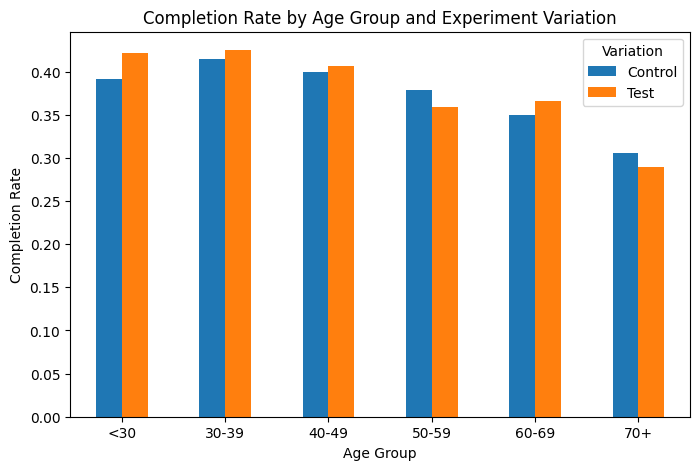

In [24]:
import matplotlib.pyplot as plt

# Prepare data
completion_age_var = df.groupby(
    ["age_group", "Variation"]
)["completion_rate"].mean().unstack()

# Create chart
completion_age_var.plot(kind="bar", figsize=(8,5))

# Labels
plt.title("Completion Rate by Age Group and Experiment Variation")
plt.xlabel("Age Group")
plt.ylabel("Completion Rate")
plt.xticks(rotation=0)

plt.show()


## Error Rate by Age Group

We now explore whether certain age groups experience more process errors during the client journey.

This helps identify potential usability challenges across demographic segments.

In [16]:
# Error rate by age group

df.groupby("age_group")["error_rate"].mean().sort_index()

age_group
<30      0.453703
30-39    0.445040
40-49    0.488166
50-59    0.537761
60-69    0.551985
70+      0.574676
Name: error_rate, dtype: float64

### Error rate observations by age group

- Error rates increase progressively with age.
- Clients below 40 show the lowest proportion of process errors.
- Clients aged 60+ experience the highest error rates in the dataset.
- The 70+ segment has the highest error frequency overall.
- This pattern may indicate that older users face more usability difficulties during the process flow.
- The redesigned experience may require additional accessibility or simplification improvements for older client segments.

## Average Steps per Client by Age Group

We now analyze how many process steps clients complete on average across different age segments.

This helps evaluate whether some demographic groups require more navigation effort during the process.

In [17]:
# Average steps per client by age group

df.groupby("age_group")["avg_steps_client"].mean().sort_index()

age_group
<30      4.863364
30-39    4.753607
40-49    4.895066
50-59    5.012531
60-69    5.026459
70+      4.693856
Name: avg_steps_client, dtype: float64

### Average steps observations by age group

- The average number of steps per client remains relatively stable across age groups.
- Clients aged 50–69 show the highest average number of process steps.
- This may suggest that middle-to-older age groups require slightly more navigation effort during the process.
- Interestingly, the 70+ group shows a lower average number of steps compared to the 50–69 segments.
- One possible explanation is that some older users abandon the process earlier instead of continuing through additional steps.

## Error Rate by Age Group and Experiment Variation

We now compare process error rates across age groups separately for the Test and Control variations.

This helps evaluate whether the redesigned experience affects demographic segments differently in terms of usability and process friction.

In [18]:
# Error rate by age group and experiment variation

df.groupby(["age_group", "Variation"])["error_rate"].mean().unstack()

Variation,Control,Test
age_group,,
<30,0.430549,0.473619
30-39,0.424046,0.462563
40-49,0.458455,0.514341
50-59,0.486031,0.583816
60-69,0.506958,0.591915
70+,0.520986,0.623049


### Error rate observations by age group and experiment variation

- Across every age segment, the Test variation shows higher error rates than the Control variation.
- Error rates increase steadily with age in both experiment groups.
- The largest error rates are observed among clients aged 60+ and especially 70+.
- The redesigned experience appears to introduce additional process friction compared to the original flow.
- Older users seem to be disproportionately affected by the redesign, suggesting potential usability or accessibility challenges for senior client segments.

### Visualization: Error Rate by Age Group and Experiment Variation

The following chart compares process error rates across demographic age segments for both experiment variations.

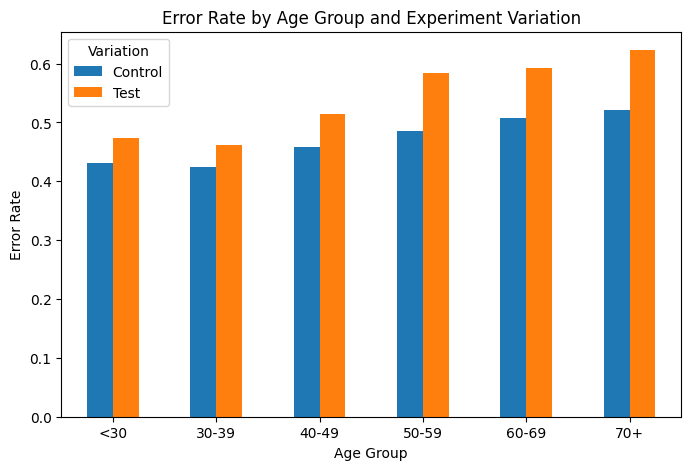

In [25]:
# Prepare data
error_age_var = df.groupby(
    ["age_group", "Variation"]
)["error_rate"].mean().unstack()

# Create chart
error_age_var.plot(kind="bar", figsize=(8,5))

# Labels
plt.title("Error Rate by Age Group and Experiment Variation")
plt.xlabel("Age Group")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)

plt.show()

## Completion Rate by Gender and Experiment Variation

We now compare completion rates across gender categories for both experiment variations.

This helps evaluate whether the redesigned experience affects demographic groups differently.

In [19]:
# Completion rate by gender and experiment variation

df.groupby(["gendr", "Variation"])["completion_rate"].mean().unstack()

Variation,Control,Test
gendr,,
F,0.369000,0.365649
M,0.401631,0.403476
U,0.373596,0.395339


### Completion rate observations by gender and experiment variation

- Completion rates are relatively similar across gender groups.
- Male clients show the highest completion rates overall.
- Female clients have the lowest completion rates among the available gender categories.
- The Test variation slightly improves completion rates for male and unknown-gender clients.
- For female clients, the redesigned experience shows a very small decrease in completion rate compared to the Control group.
- Overall, gender appears to have a weaker influence on completion behavior than age.

## Error Rate by Gender and Experiment Variation

We now compare process error rates across gender categories for both experiment variations.

This helps identify whether some demographic groups experience more friction or usability issues in the redesigned process.

In [20]:
# Error rate by gender and experiment variation

df.groupby(["gendr", "Variation"])["error_rate"].mean().unstack()

Variation,Control,Test
gendr,,
F,0.473084,0.550826
M,0.453827,0.526011
U,0.471051,0.521256


### Error rate observations by gender and experiment variation

- Across all gender categories, the Test variation produces higher error rates than the Control variation.
- Female clients show the highest error rates overall.
- Male clients have slightly lower error rates compared to the other gender groups.
- The increase in error rates between Control and Test is consistent across all gender categories.
- This suggests that the redesigned experience may introduce additional usability friction regardless of gender.
- Compared to age, gender differences appear relatively moderate.

## Completion Rate by Client Tenure

We now analyze whether completion behavior differs across client tenure segments.

This helps evaluate whether long-term and newer clients respond differently to the redesigned experience.

In [21]:
# Create tenure groups

df["tenure_group"] = pd.cut(
    df["clnt_tenure_mnth"],
    bins=[0, 60, 120, 180, 240, 1000],
    labels=["0-5y", "5-10y", "10-15y", "15-20y", "20y+"]
)

# Check tenure group distribution

df["tenure_group"].value_counts().sort_index()

tenure_group
0-5y       4249
5-10y     18568
10-15y    12000
15-20y     7682
20y+       7988
Name: count, dtype: int64

## Completion Rate by Client Tenure Group

We now compare completion behavior across different client tenure segments.

This helps identify whether newer or long-term clients adapt differently to the redesigned experience.

In [22]:
# Completion rate by tenure group

df.groupby("tenure_group")["completion_rate"].mean().sort_index()

tenure_group
0-5y      0.386209
5-10y     0.391695
10-15y    0.388750
15-20y    0.377506
20y+      0.372058
Name: completion_rate, dtype: float64

### Key observations

- Completion rates are relatively similar across tenure groups overall.
- Clients with 5–10 years of tenure show the highest completion rates.
- Very long-term clients (20y+) show the lowest completion rates.
- This may suggest that highly established users experience more friction with the redesigned process.
- Differences across tenure groups appear smaller than the differences observed across age groups.
- Overall, age seems to have a stronger relationship with completion behavior than client tenure.

## Completion Rate by Tenure Group and Experiment Variation

We now compare completion behavior across tenure segments separately for the Test and Control groups.

This helps evaluate whether newer or long-term clients respond differently to the redesigned experience.

In [23]:
# Completion rate by tenure group and experiment variation

df.groupby(["tenure_group", "Variation"])["completion_rate"].mean().unstack()

Variation,Control,Test
tenure_group,,
0-5y,0.376834,0.394366
5-10y,0.380763,0.401018
10-15y,0.390456,0.387239
15-20y,0.378725,0.376436
20y+,0.375629,0.368858


### Key observations

- Clients with lower and mid-level tenure (0–15 years) show slightly higher completion rates in the Test variation.
- The strongest improvement appears in the 5–10 year segment.
- For clients with 15+ years of tenure, the redesigned experience does not improve completion behavior.
- In the 20y+ segment, the Control group slightly outperforms the Test group.
- This may suggest that long-term clients are more attached to the old process and experience greater friction with the redesign.
- Overall, the redesigned experience seems more effective for newer and moderately established clients than for very long-term customers.

# Overall Insights

Based on the demographic and KPI analysis, several important behavioral patterns emerge across the experiment groups.

### Main findings

- Age appears to be the strongest demographic factor influencing client behavior.
- Younger clients generally achieve higher completion rates and lower error rates.
- Older clients, especially users aged 60+, experience substantially higher error rates and lower completion success.
- The redesigned Test experience appears to benefit younger users more consistently than older users.
- Gender differences exist but appear relatively small compared to age-related effects.
- Client tenure shows moderate influence on completion behavior, with very long-term clients responding less positively to the redesign.

### Business interpretation

- The redesigned experience may introduce additional usability friction for older and highly established clients.
- Long-term users may be more accustomed to the previous workflow and therefore less adaptable to interface changes.
- Younger and digitally engaged clients appear to navigate the redesigned process more successfully.

### Recommendations

- Consider simplifying navigation and reducing friction points for older demographic groups.
- Conduct deeper UX investigation into where older users encounter process errors.
- Explore whether personalized onboarding or guided flows could improve completion rates for long-term clients.
- Future analysis could investigate step-level drop-offs and interaction patterns in more detail.

### Tableau opportunities

This dataset is well suited for interactive Tableau dashboards including:
- Completion rate by demographic segment
- Error rate by age and experiment variation
- KPI comparison between Test and Control groups
- Demographic filtering and drill-down analysis